# 1. Load Data & Libararies

In [121]:
TRAINING_SIZE = 0.7
RANDOM_STATE = 42

In [122]:
import warnings
from sklearn.exceptions import FitFailedWarning

# Suppress FutureWarnings and FitFailedWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

# Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (ConfusionMatrixDisplay, f1_score, recall_score, precision_score, accuracy_score, RocCurveDisplay, roc_curve
,classification_report, PrecisionRecallDisplay)

# Imbalance Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [124]:
df = pd.read_csv('data/clean_data_v1.csv')
df = df.drop(columns=["Unnamed: 0"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [125]:
X = df.iloc[:,:-1]
y = df.iloc[:, -1]

In [126]:
x_train, x_temp, y_train, y_temp = train_test_split(X, y, train_size=TRAINING_SIZE, random_state=RANDOM_STATE, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

print(len(x_train))
print(len(x_val))
print(len(x_test))

7000
1500
1500


# 2. Helper Methods

In [127]:
def display_metric(y_true, y_pred, name=None, ConfusionMatrix=True):


    f1 = f1_score(y_true=y_true, y_pred=y_pred)
    accuracy = accuracy_score(y_true=y_true, y_pred=y_pred)
    recall = recall_score(y_true=y_true, y_pred=y_pred)
    precision = precision_score(y_true=y_true, y_pred=y_pred)

    print("f1_score:", f"%{round(f1*100,4)}")
    print("accuracy_score:", f"%{round(accuracy*100,4)}")
    print("recall_score:", f"%{round(recall*100,4)}")
    print("precision_score:", f"%{round(precision*100,4)}")

    return f1, accuracy, recall, precision
    

In [128]:
def get_best_threshold(y_test, y_pred, printing=True):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)

    best_threshold = thresholds[best_idx]
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]

    if printing:
        print(f"Optimal Threshold: {best_threshold:.4f}")
        print(f"At this threshold -> TPR (Recall): {best_tpr:.4f}, FPR: {best_fpr:.4f}")

    return best_threshold


# 3. Pipelines

In [129]:
models = {
     "LogisticRegression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("polynomial",PolynomialFeatures(degree=3)),
            ("classifier", LogisticRegression(max_iter=5000, class_weight='balanced'))
        ]),
        {
            "classifier__C": [0.1, 1, 10],
            "classifier__penalty":["l1", "l2"],
            "classifier__solver":["liblinear", "newton-cg"]
        }
    ),
     "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"]
        }
    ),
    "DecisionTree": (DecisionTreeClassifier(random_state=RANDOM_STATE), {
        "max_depth": [3, 5, 7],
        'class_weight': ['balanced', None]
    }),
    "RandomForest": (RandomForestClassifier(random_state=RANDOM_STATE), {
        "n_estimators": [50, 100, 200],
        "max_depth":[10, 30, None],
        'class_weight': ['balanced', None]
    })
}

# 4. Training

In [131]:
"""
Fitting Models
"""
fitted_models = {}
for name, (model, params) in models.items():
    print(f"Fitting {name} model in Progress...")
    grid_search = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(x_train, y_train)
    fitted_models[name] = grid_search
    print(f"finished Fitting {name} model!")


Fitting LogisticRegression model in Progress...
finished Fitting LogisticRegression model!
Fitting SVM model in Progress...
finished Fitting SVM model!
Fitting DecisionTree model in Progress...
finished Fitting DecisionTree model!
Fitting RandomForest model in Progress...
finished Fitting RandomForest model!


In [132]:
training_results = {
    "Model":[],
    "Precision": [],
    "Recall": [],
    "F1-Score": [],
    "Accuracy":[]
}

def append_to_training_results(name, f1, accuracy, recall, precision):
    training_results['Model'].append(name)
    training_results['F1-Score'].append(f1*100)
    training_results['Accuracy'].append(accuracy*100)
    training_results['Recall'].append(recall*100)
    training_results['Precision'].append(precision*100)

In [133]:
# results = {}
# for name, (model, params) in models.items():
#     grid_search = GridSearchCV(model, params, cv=skf, scoring='accuracy', n_jobs=-1)
#     grid_search.fit(X_train, y_train)
#     best_model = grid_search.best_estimator_
#     accuracy = best_model.score(X_val, y_val)
#     results[name] = {
#         "best_model": best_model,
#         'best_score': grid_search.best_score_,
#         'best_params': grid_search.best_params_,
#         'validation_accuracy': accuracy
#     }

# 5. Validation & Evaluation

LogisticRegression
f1_score: %61.2658
accuracy_score: %79.6
recall_score: %79.085
precision_score: %50.0


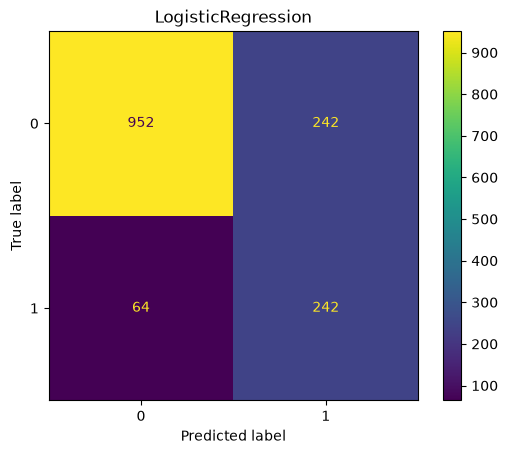

LogisticRegression_best_threshold
f1_score: %61.2658
accuracy_score: %79.6
recall_score: %79.085
precision_score: %50.0


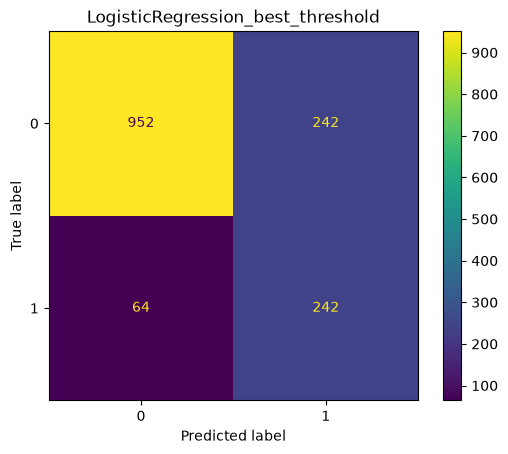

SVM
f1_score: %60.076
accuracy_score: %79.0
recall_score: %77.451
precision_score: %49.0683


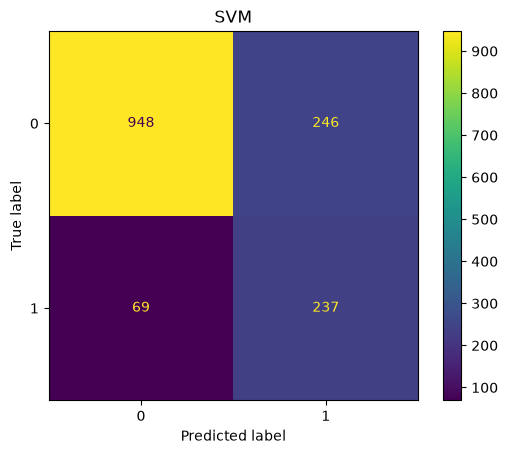

SVM_best_threshold
f1_score: %60.0503
accuracy_score: %78.8
recall_score: %78.1046
precision_score: %48.7755


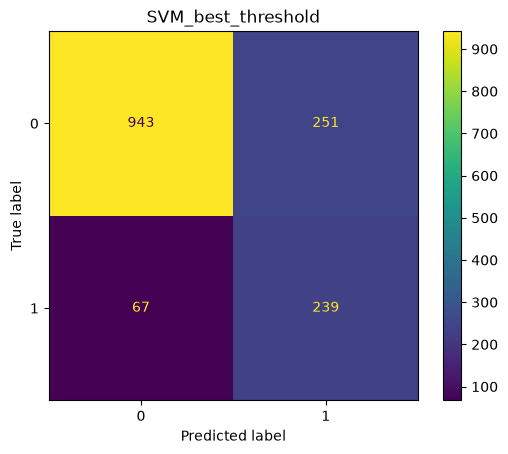

DecisionTree
f1_score: %51.3158
accuracy_score: %85.2
recall_score: %38.2353
precision_score: %78.0


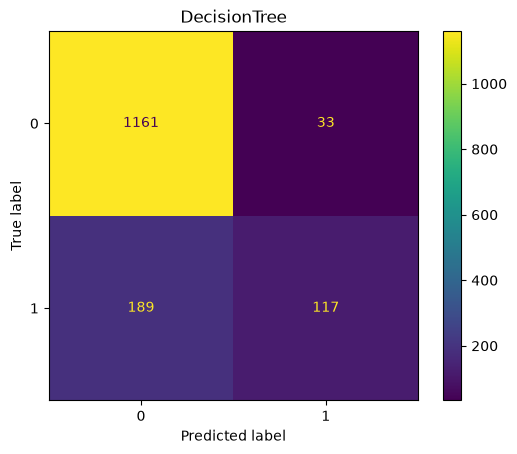

DecisionTree_best_threshold
f1_score: %62.3688
accuracy_score: %83.2667
recall_score: %67.9739
precision_score: %57.6177


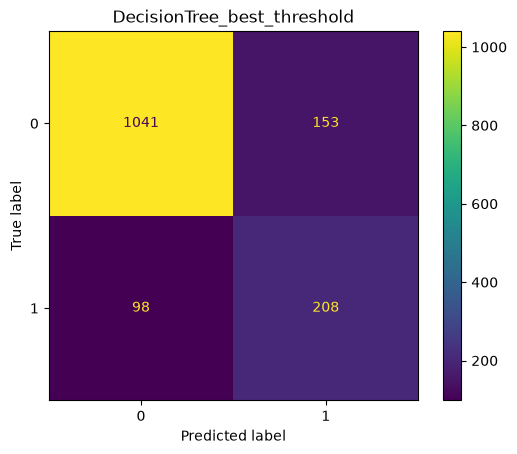

RandomForest
f1_score: %58.5774
accuracy_score: %86.8
recall_score: %45.7516
precision_score: %81.3953


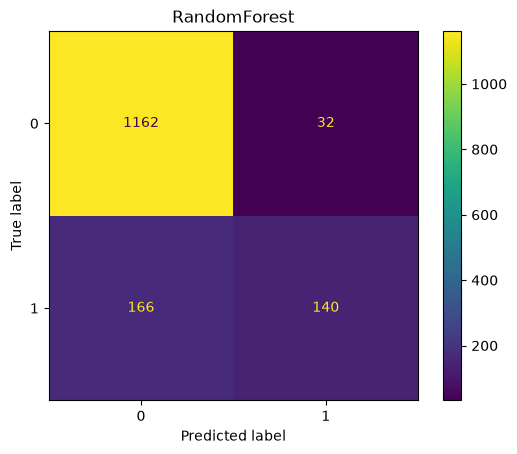

RandomForest_best_threshold
f1_score: %61.8989
accuracy_score: %79.4
recall_score: %82.0261
precision_score: %49.703


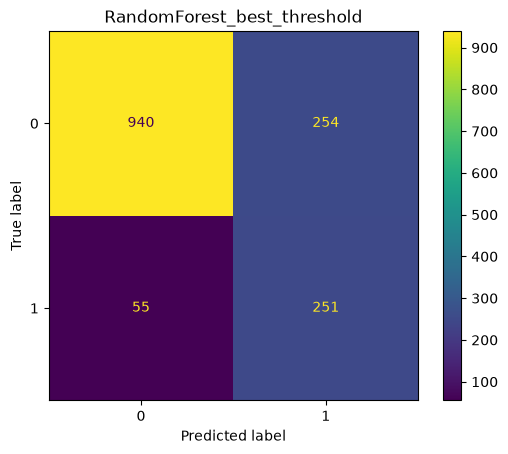

In [134]:
best_threshold_models = {}

for name_1, model in fitted_models.items():

    y_pred_1 = model.predict(x_val)
    y_pred_probs = model.predict_proba(x_val)[:,1]

    name_2 = name_1 + "_best_threshold"
    best_threshold = get_best_threshold(y_val, y_pred_probs, printing=False)
    y_pred_2 = (y_pred_probs >= best_threshold).astype(int)

    best_threshold_models[name_1] = (model, best_threshold)

    for name, y_pred in [(name_1, y_pred_1), (name_2, y_pred_2)]:
        print(name)
        f1, acc, recall, precision = display_metric(y_val, y_pred)
        append_to_training_results(name, f1, acc, recall, precision)

        # Confusion Matrices
        ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
        plt.title(name)
        plt.show()
        print("="*100)



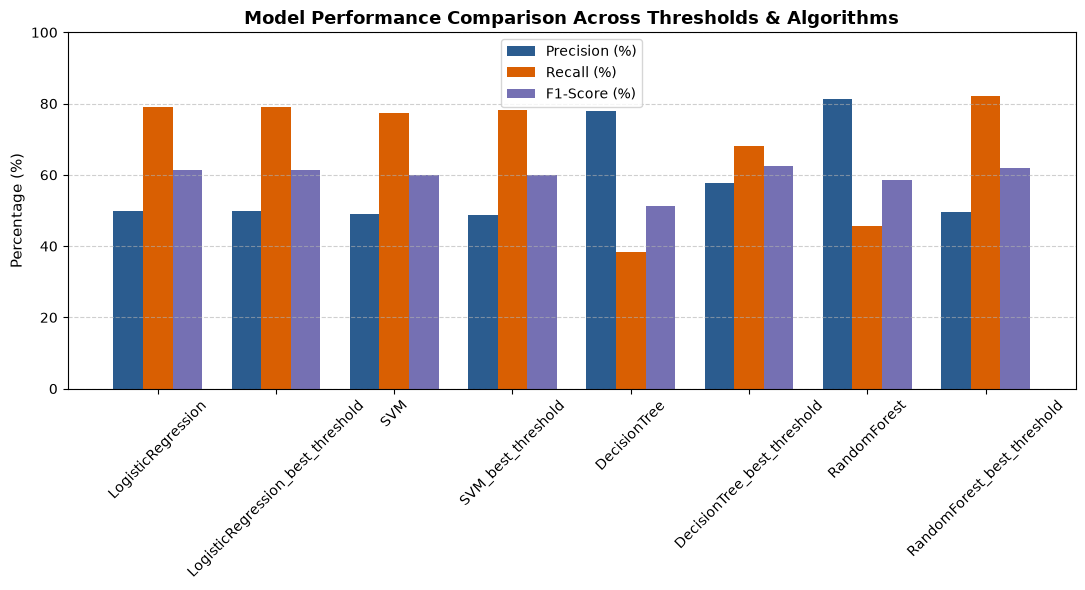

In [135]:
training_results_df = pd.DataFrame(training_results)

x = np.arange(len(training_results_df["Model"]))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(
    x - width,
    training_results_df["Precision"],
    width,
    label="Precision (%)",
    color="#2b5c8f",
)
ax.bar(x, training_results_df["Recall"], width, label="Recall (%)", color="#d95f02")
ax.bar(
    x + width,
    training_results_df["F1-Score"],
    width,
    label="F1-Score (%)",
    color="#7570b3",
)

# Styling
ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_title(
    "Model Performance Comparison Across Thresholds & Algorithms",
    fontsize=13,
    fontweight="bold",
)
plt.xticks(rotation=45)
ax.set_xticks(x)
ax.set_xticklabels(training_results_df["Model"], fontsize=10)
ax.set_ylim(0, 100)
ax.legend(frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

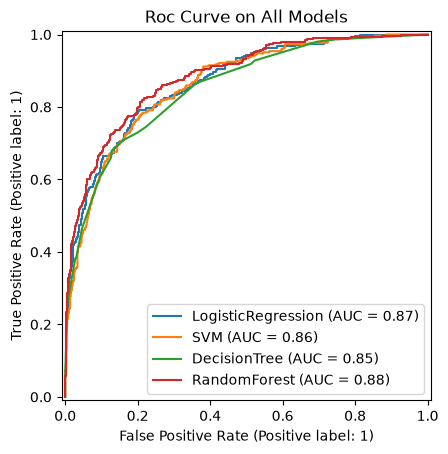

In [138]:
fig, ax = plt.subplots()
plt.title("Roc Curve on All Models")

for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, x_val, y_val, ax=ax, name=name)
plt.show()

# 6. Testing

LogisticRegression
              precision    recall  f1-score   support

           0       0.93      0.79      0.86      1195
           1       0.48      0.75      0.59       305

    accuracy                           0.79      1500
   macro avg       0.71      0.77      0.72      1500
weighted avg       0.84      0.79      0.80      1500


LogisticRegression (Best Threshold: 0.5)
              precision    recall  f1-score   support

           0       0.93      0.79      0.86      1195
           1       0.48      0.75      0.59       305

    accuracy                           0.79      1500
   macro avg       0.71      0.77      0.72      1500
weighted avg       0.84      0.79      0.80      1500



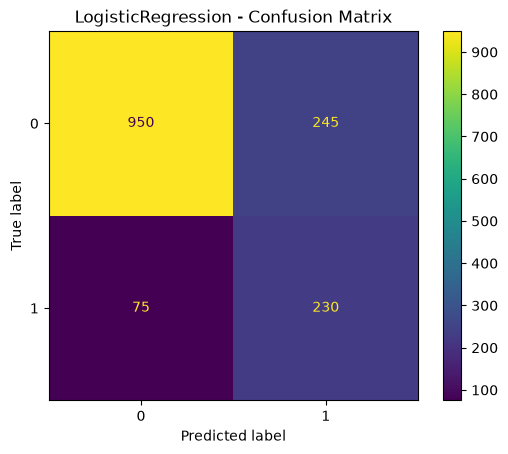

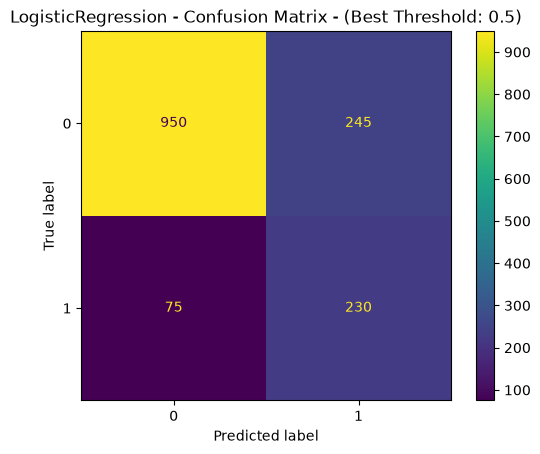

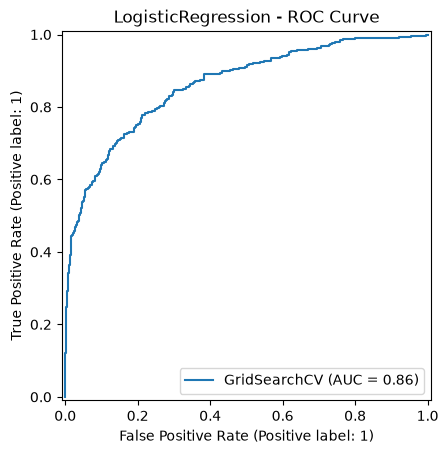

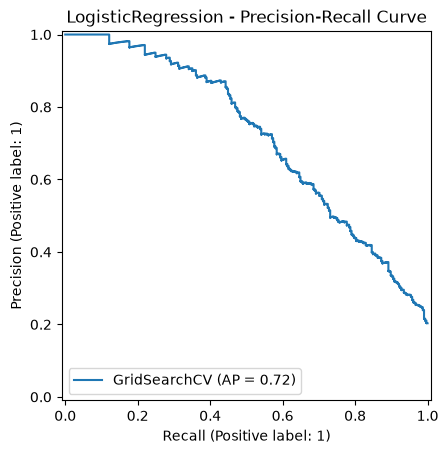




SVM
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1195
           1       0.49      0.75      0.59       305

    accuracy                           0.79      1500
   macro avg       0.71      0.77      0.72      1500
weighted avg       0.84      0.79      0.80      1500


SVM (Best Threshold: 0.2137)
              precision    recall  f1-score   support

           0       0.93      0.79      0.86      1195
           1       0.48      0.75      0.59       305

    accuracy                           0.79      1500
   macro avg       0.70      0.77      0.72      1500
weighted avg       0.84      0.79      0.80      1500



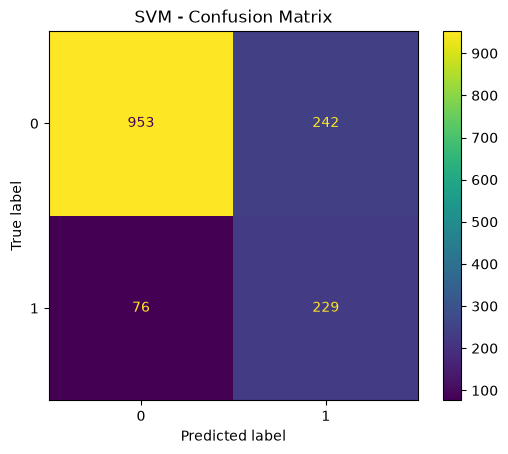

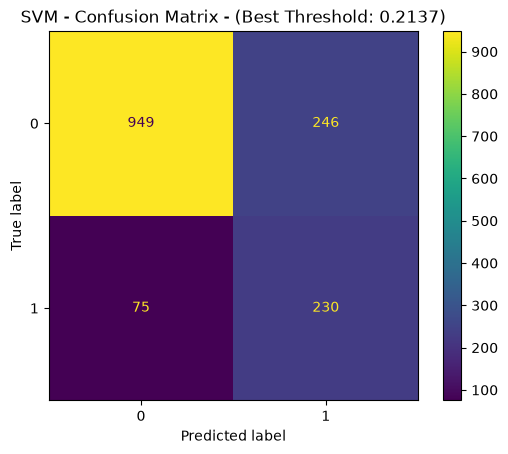

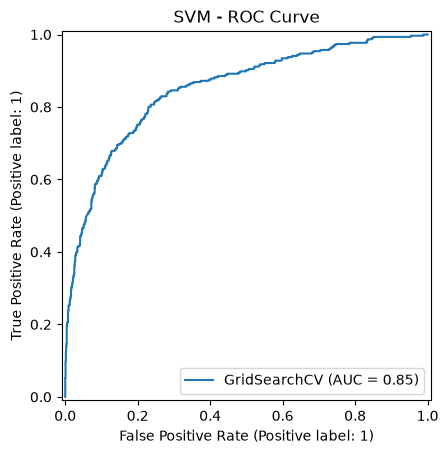

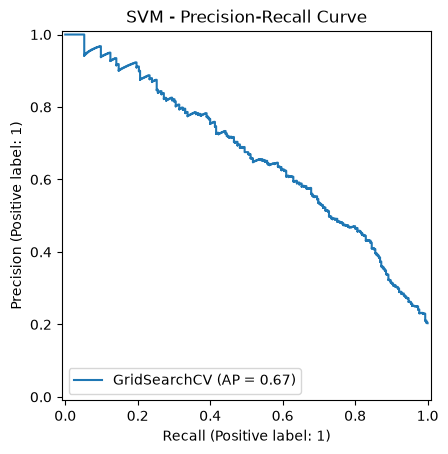




DecisionTree
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1195
           1       0.87      0.40      0.55       305

    accuracy                           0.87      1500
   macro avg       0.87      0.69      0.74      1500
weighted avg       0.87      0.87      0.85      1500


DecisionTree (Best Threshold: 0.3077)
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1195
           1       0.60      0.67      0.63       305

    accuracy                           0.84      1500
   macro avg       0.75      0.78      0.76      1500
weighted avg       0.85      0.84      0.84      1500



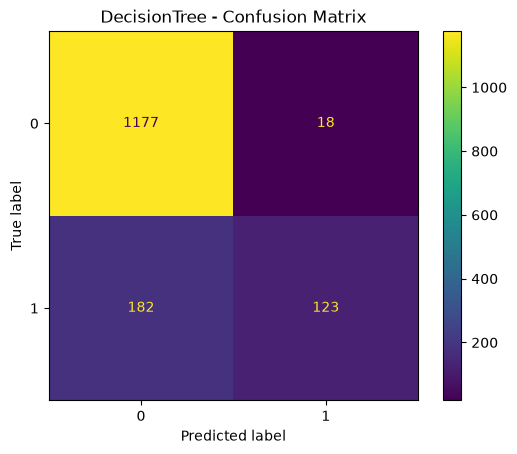

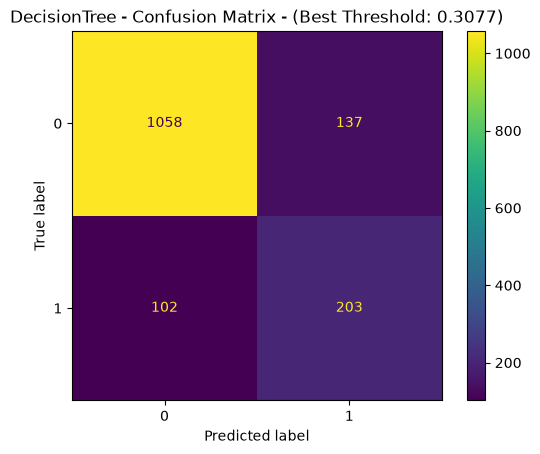

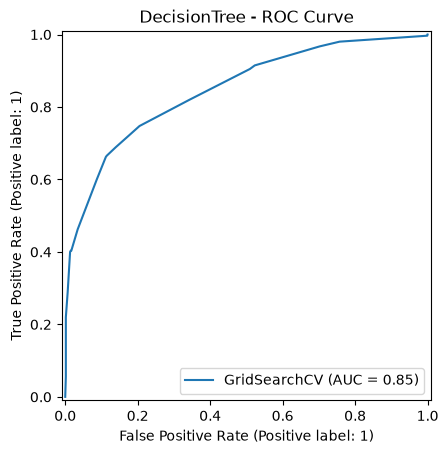

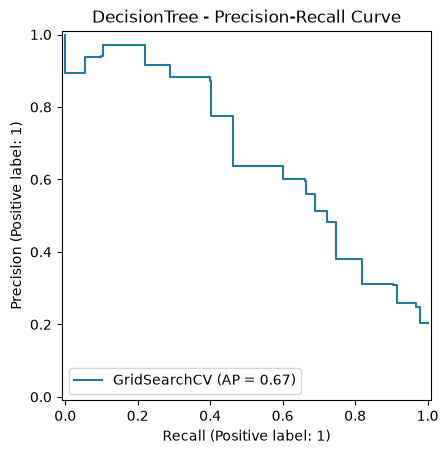




RandomForest
              precision    recall  f1-score   support

           0       0.88      0.98      0.92      1195
           1       0.83      0.46      0.59       305

    accuracy                           0.87      1500
   macro avg       0.85      0.72      0.76      1500
weighted avg       0.87      0.87      0.86      1500


RandomForest (Best Threshold: 0.1988)
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1195
           1       0.47      0.77      0.58       305

    accuracy                           0.78      1500
   macro avg       0.70      0.77      0.71      1500
weighted avg       0.84      0.78      0.79      1500



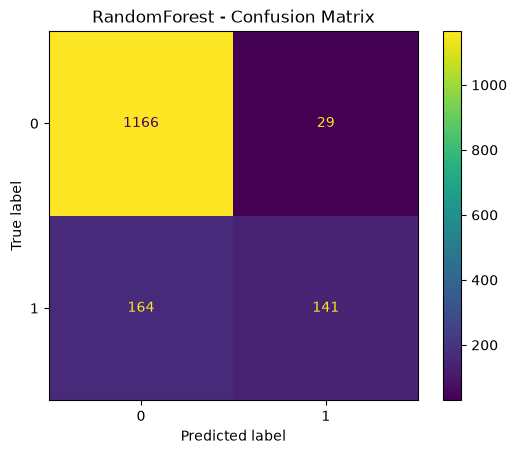

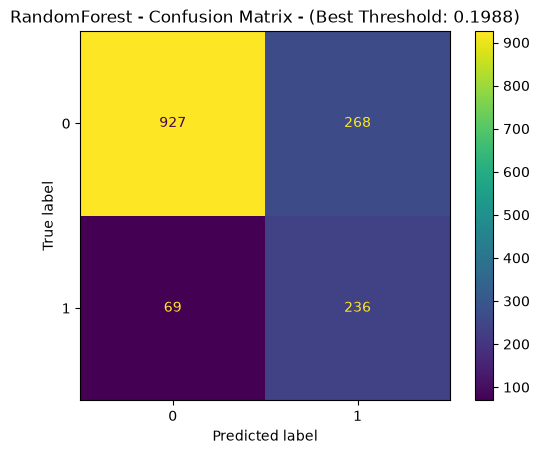

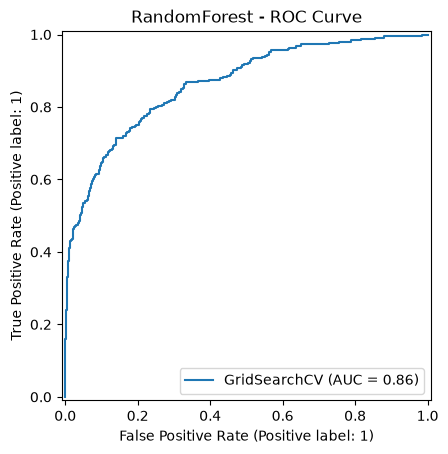

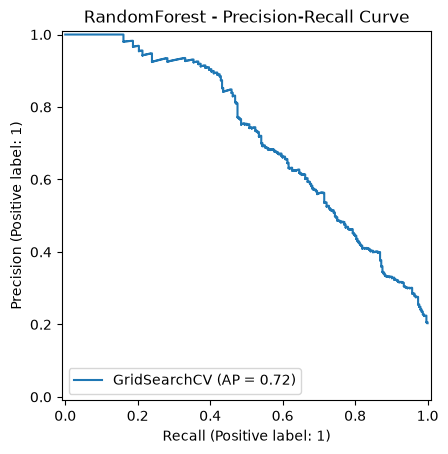

In [139]:
for name, (model, best_threshold) in best_threshold_models.items():
    y_pred_from_best_threshold = (model.predict_proba(x_test)[:,1] >= best_threshold).astype(int)

    # Confusion Table
    print("="*100,f"\n{name}")
    print("="*100)
    print(classification_report(y_test, model.predict(x_test)))

    print(f"\n{name} (Best Threshold: {round(best_threshold, 4)})")
    print(classification_report(y_test, y_pred_from_best_threshold))

    ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_from_best_threshold)
    plt.title(f"{name} - Confusion Matrix - (Best Threshold: {round(best_threshold, 4)})")
    plt.show()

    RocCurveDisplay.from_estimator(model, x_test, y_test)
    plt.title(f"{name} - ROC Curve")
    plt.show()

    PrecisionRecallDisplay.from_estimator(model, x_test, y_test)
    plt.title(f"{name} - Precision-Recall Curve")
    plt.show()

    print("\n\n")




# 7. LLM Integration (LM Studio) — Zero-shot, Few-shot, Reasoning

In [ ]:
import requests

lm_studio_url = "http://192.168.8.95:3346/v1/chat/completions"
lm_studio_model = "lfm2.5-1.2b-instruct"
lm_studio_api_key = "PASTE_YOUR_LM_STUDIO_API_KEY_HERE"

def call_lm_studio(messages):
    response = requests.post(
        lm_studio_url,
        headers={"Authorization": f"Bearer {lm_studio_api_key}"},
        json={
            "model": lm_studio_model,
            "messages": messages,
            "temperature": 0.3,
            "max_tokens": 400,
        },
    )
    return response.json()["choices"][0]["message"]["content"]


In [ ]:
# grab one real at-risk customer from the test set to ground the prompts
best_model, best_threshold = best_threshold_models["RandomForest"]

x_test_reset = x_test.reset_index(drop=True)
probs = best_model.predict_proba(x_test_reset)[:, 1]
at_risk_index = x_test_reset.index[probs >= best_threshold][0]

customer_profile = x_test_reset.iloc[at_risk_index].to_dict()
customer_profile["predicted_churn_probability"] = round(float(probs[at_risk_index]), 3)
customer_profile


### 7.1 Zero-shot

In [ ]:
zero_shot_messages = [
    {"role": "system", "content": "You are a customer retention analyst for a bank."},
    {"role": "user", "content": f"Customer profile: {customer_profile}\n\nIn 3-4 sentences, assess churn risk and suggest one retention action."},
]
print(call_lm_studio(zero_shot_messages))


### 7.2 Few-shot

In [ ]:
few_shot_messages = [
    {"role": "system", "content": "You are a customer retention analyst for a bank. Follow the format in the examples."},
    {"role": "user", "content": (
        "Example 1:\nProfile: {'Age': 58, 'Balance': 0, 'NumOfProducts': 1, 'IsActiveMember': 0, 'predicted_churn_probability': 0.81}\n"
        "Risk: HIGH\nAction: Call the customer, waive fees, offer a relationship-manager check-in.\n\n"
        "Example 2:\nProfile: {'Age': 30, 'Balance': 60000, 'NumOfProducts': 2, 'IsActiveMember': 1, 'predicted_churn_probability': 0.12}\n"
        "Risk: LOW\nAction: No immediate action; standard loyalty email.\n\n"
        f"Now do the same for:\nProfile: {customer_profile}\nRisk:\nAction:"
    )},
]
print(call_lm_studio(few_shot_messages))


### 7.3 Reasoning

In [ ]:
reasoning_messages = [
    {"role": "system", "content": "You are a customer retention analyst for a bank. Think step by step."},
    {"role": "user", "content": (
        f"Customer profile: {customer_profile}\n\n"
        "Step 1: list factors that increase or decrease churn risk.\n"
        "Step 2: weigh the factors against each other.\n"
        "Step 3: give a final risk level (LOW/MEDIUM/HIGH) and one concrete retention action."
    )},
]
print(call_lm_studio(reasoning_messages))
